#### Import numpy & keras

In [3]:
import numpy as np
import keras
from datasets import load_dataset, DatasetDict, Image
import datetime

In [4]:
import tensorflow as tf
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

2.21.0
Num GPUs Available:  0
[]


### Bilder normalisieren

In [5]:
def transform(example):
    image = np.array(example["image"], dtype=np.float32) / 255.0
    return {"image": image, "label": example["label"]}


#### 1. get training data

In [6]:
import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

ds = load_dataset("jonathan-roberts1/NWPU-RESISC45")
print(ds.shape)

train_data = ds["train"]
split_1 = train_data.train_test_split(
    test_size=0.15,
    seed=42,          # sorgt dafür, dass Validation immer gleich bleibt
    shuffle=True
)

validation_dataset = split_1["test"]

12.2.0


{'train': (31500, 2)}


In [7]:
remaining_dataset = split_1["train"]
split_2 = remaining_dataset.train_test_split(
    test_size=0.25,
    seed=42,
    shuffle=True
)

train_ds = split_2["train"]
test_ds = split_2["test"]

# DatasetDict erzeugen
final_dataset = DatasetDict({
    "train": train_ds,
    "validation": validation_dataset,
    "test": test_ds
})
final_dataset = final_dataset.cast_column("image", Image())
final_dataset.with_format("tf")
final_dataset = final_dataset.with_transform(transform)

print(final_dataset)

train_images = (final_dataset["train"]["image"])
test_images = (final_dataset["test"]["image"])

train_labels = (final_dataset["train"]["label"])
test_labels = (final_dataset["test"]["label"])

tf_train = final_dataset["train"].to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=128,
    shuffle=True
)

tf_test = final_dataset["test"].to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=128
)

class_names = final_dataset["train"].features["label"].names
print(class_names)

img_shape = np.array(final_dataset["train"][0]["image"]).shape
print(img_shape)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20081
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 6694
    })
})


C:\Users\marie\AppData\Local\Programs\Python\Python312\Lib\site-packages\datasets\arrow_dataset.py:418: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud', 'commercial area', 'dense residential', 'desert', 'forest', 'freeway', 'golf course', 'ground track field', 'harbor', 'industrial area', 'intersection', 'island', 'lake', 'meadow', 'medium residential', 'mobile home park', 'mountain', 'overpass', 'palace', 'parking lot', 'railway', 'railway station', 'rectangular farmland', 'river', 'roundabout', 'runway', 'sea ice', 'ship', 'snowberg', 'sparse residential', 'stadium', 'storage tank', 'tennis court', 'terrace', 'thermal power station', 'wetland']
(256, 256, 3)


#### 2. define architecture

In [8]:
# Import a model from /models/*
from models.four_block_cnn import generateModel
model_name = "example_from_presentation"

load model

In [15]:
#model = generateModel(img_shape)
model = keras.models.load_model("./models/" + model_name + ".keras")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        11,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,695 (1.78 MB)

 Trainable params: 466,733 (1.78 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

#### 3. set training parameter and fit model

In [10]:
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=20,
    callbacks=[tensorboard_callback]
)
model.save("./models/model2.keras")

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.1720 - loss: 3.2085 - val_accuracy: 0.0360 - val_loss: 3.9632
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.2668 - loss: 2.7404 - val_accuracy: 0.0205 - val_loss: 4.0311
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.3075 - loss: 2.5528 - val_accuracy: 0.1743 - val_loss: 3.1265
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.3388 - loss: 2.4039 - val_accuracy: 0.3446 - val_loss: 2.4144
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.3607 - loss: 2.3053 - val_accuracy: 0.4382 - val_loss: 2.1077
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.3825 - loss: 2.2116 - val_accuracy: 0.3845 - val_loss: 2.1317
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.3986 - loss: 2.1307 - val_accuracy: 0.3771 - val_loss: 2.2129
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.4190 - loss: 2.0659 - val_accu

In [11]:
%load_ext tensorboard
%tensorboard --logdir logs/example_from_presentation

#### 4. predict output 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted: runway
True: desert


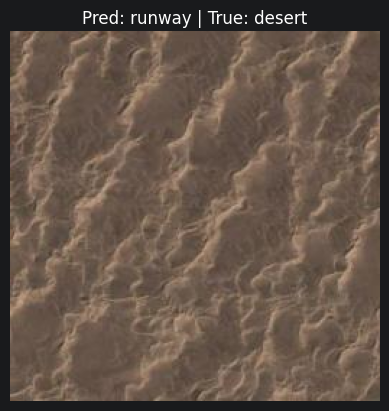

In [12]:
prediction = model.predict(test_images[:1])

predicted_idx = np.argmax(prediction)

true_idx = test_labels[0]

print("Predicted:", class_names[predicted_idx])
print("True:", class_names[true_idx])

# Bild anzeigen
img = test_images[0]

plt.imshow(img)
plt.title(f"Pred: {class_names[predicted_idx]} | True: {class_names[true_idx]}")
plt.axis("off")
plt.show()